In [ ]:

pip install numpy pandas matplotlib seaborn scikit-learn torch catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
import torch

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

TRAINING DATA STATISTICS
         age_group  identity_code  cultural_background  upbringing_influence  \
count  1913.000000    1913.000000          1913.000000           1913.000000   
mean     16.456351       0.514375             0.872974              1.764245   
std       1.124705       0.499924             1.031951              0.988605   
min      15.000000       0.000000             0.000000              0.000000   
25%      15.000000       0.000000             0.000000              1.000000   
50%      16.000000       1.000000             0.000000              2.000000   
75%      17.000000       1.000000             2.000000              2.000000   
max      18.000000       1.000000             3.000000              4.000000   

       focus_intensity  consistency_score  external_guidance_usage  \
count      1913.000000        1913.000000              1913.000000   
mean          9.748506          14.618400                 0.302143   
std           5.702764           8.485326   

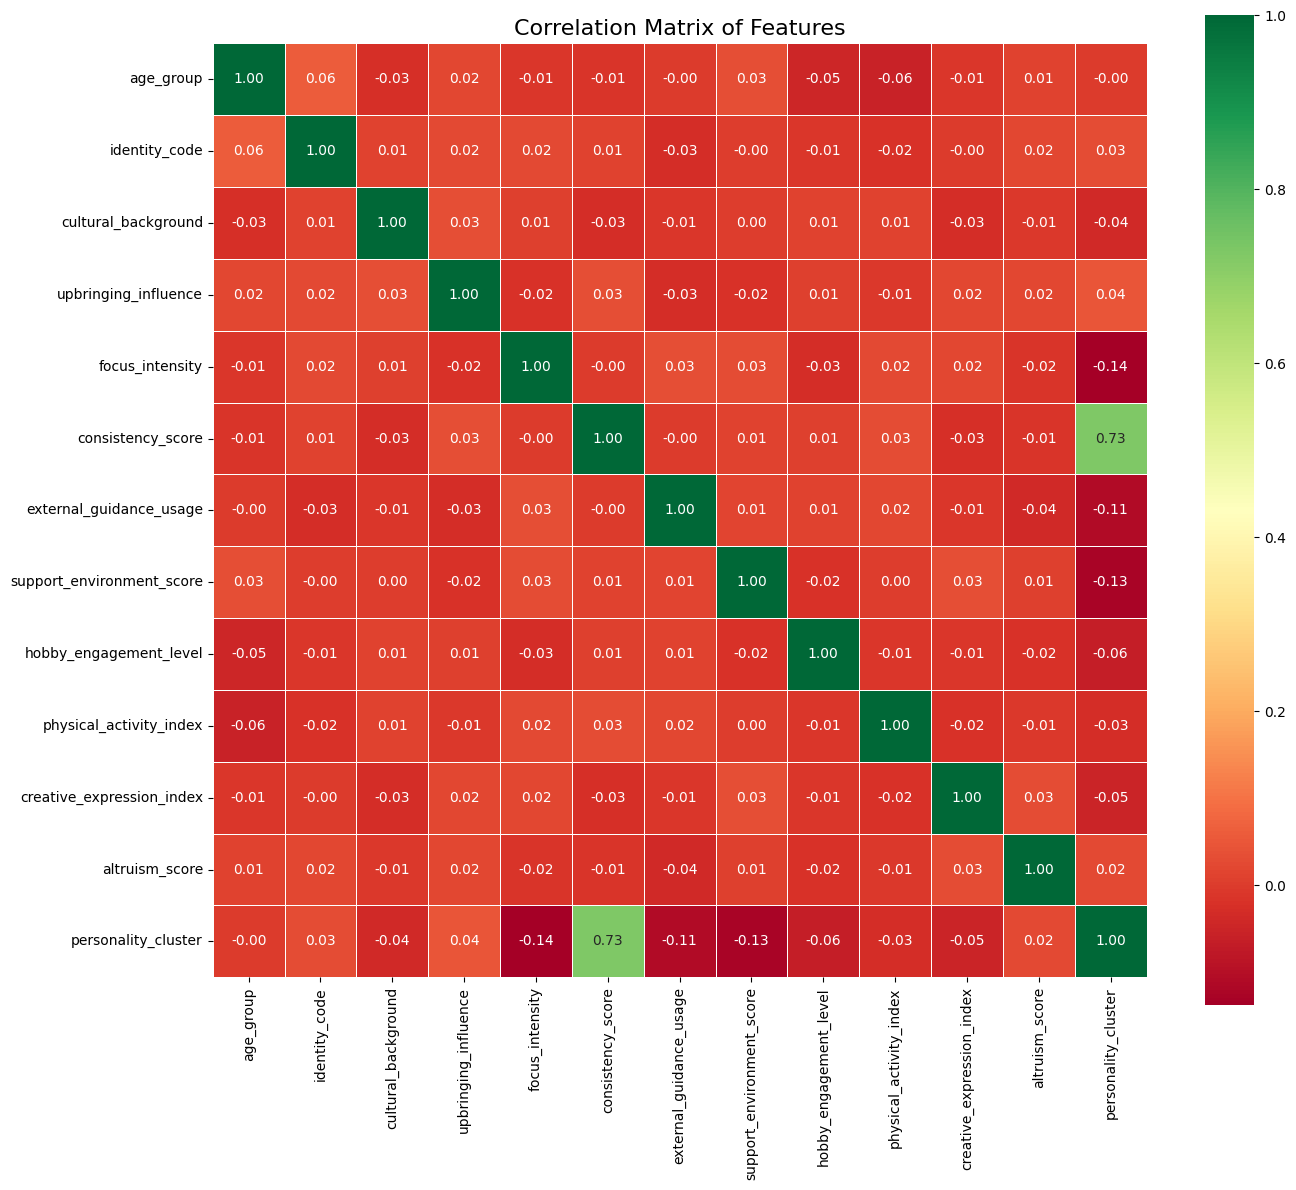

Generating t-SNE Plot...


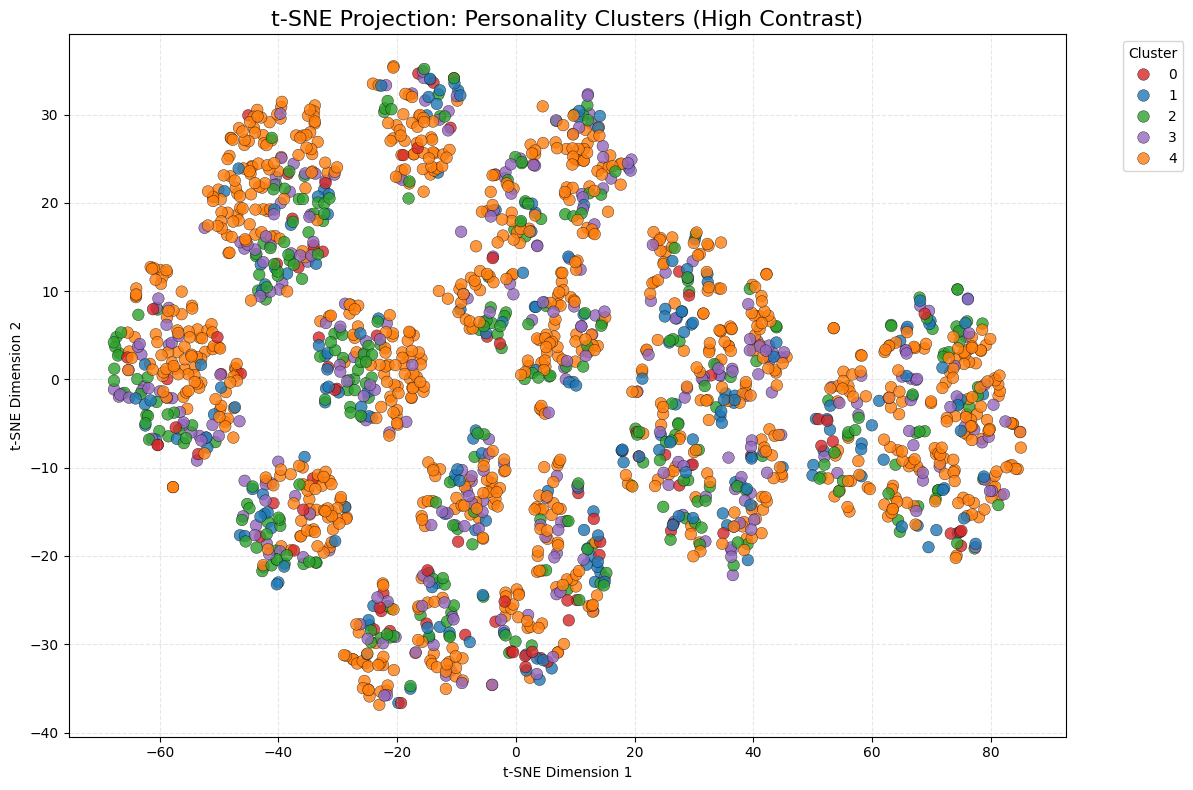

Generating Box Plots...


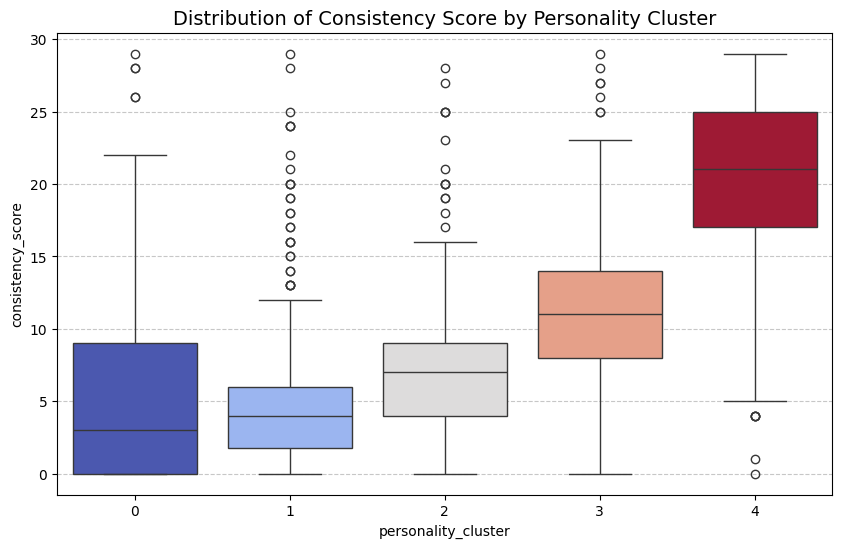

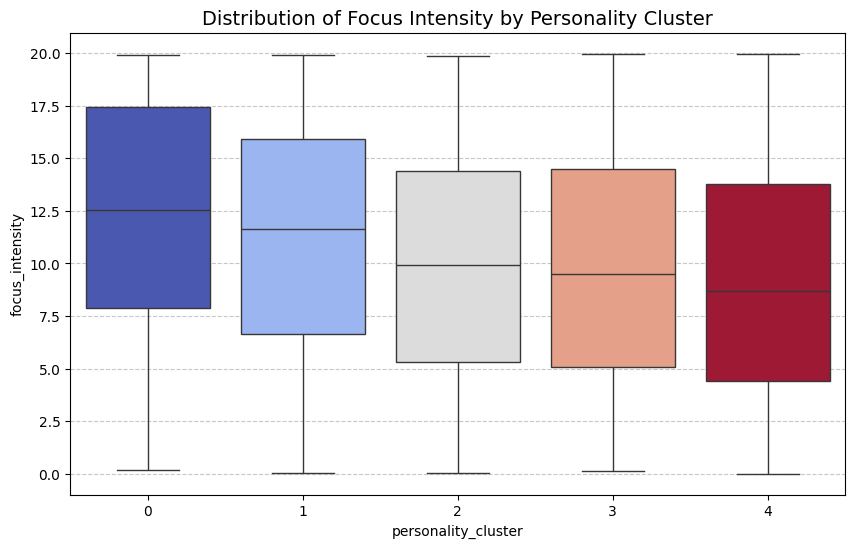

EDA Completed Successfully.


In [ ]:
""" EDA """

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("TRAINING DATA STATISTICS")
print(train_df.describe())
print("\n")
print(train_df.info())

print("TEST DATA STATISTICS")
print(test_df.describe())
print("\n")
print(test_df.info())


print("\nGenerating Correlation Matrix...")

# Compute Correlation
corr_matrix = train_df.corr()

# Plot Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='RdYlGn',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()


print("Generating t-SNE Plot...")

# Prepare Data
# Drop target and ID
X_eda = train_df.drop(['personality_cluster', 'participant_id'], axis=1, errors='ignore')
y_eda = train_df['personality_cluster']

# Standardize
scaler = StandardScaler()
X_eda_numeric = X_eda.select_dtypes(include=[np.number])
X_scaled = scaler.fit_transform(X_eda_numeric)

# Compute t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(X_scaled)

# Plot t-SNE
# FIX: Use Integer keys (0-4) to match the numerical data
custom_colors = {
    0: '#D62728',  # Cluster_A
    1: '#1F77B4',  # Cluster_B
    2: '#2CA02C',  # Cluster_C
    3: '#9467BD',  # Cluster_D
    4: '#FF7F0E'   # Cluster_E
}

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=y_eda,
    palette=custom_colors,   # This will now match the integer values in y_eda
    s=70,
    alpha=0.8,
    edgecolor='k',
    linewidth=0.3
)

plt.title('t-SNE Projection: Personality Clusters (High Contrast)', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('tsne_plot.png')
plt.show()

print("Generating Box Plots...")
cluster_order = [0, 1, 2, 3, 4]

# Box Plot for Consistency Score
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='personality_cluster',
    y='consistency_score',
    data=train_df,
    order=cluster_order,
    hue='personality_cluster',
    palette='coolwarm',
    dodge=False
)
plt.legend([],[], frameon=False)
plt.title('Distribution of Consistency Score by Personality Cluster', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig('boxplot_consistency.png')
plt.show()

# Box Plot for Focus Intensity
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='personality_cluster',
    y='focus_intensity',
    data=train_df,
    order=cluster_order,
    hue='personality_cluster',
    palette='coolwarm',
    dodge=False
)
plt.legend([],[], frameon=False)
plt.title('Distribution of Focus Intensity by Personality Cluster', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig('boxplot_focus.png')
plt.show()

print("EDA Completed Successfully.")

In [ ]:
""" HYPERPARAMETER FINE-TUNING """

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

model_to_use = input("Enter the model name: ")

models_params = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.01,0.1,1,10],
            'solver': ['lbfgs'],
        }
    },
    'SVC': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1,1,4,10],
            'kernel': ['rbf', 'poly'],
            'gamma': ['scale', 'auto'],
        }
    },
    'MLPClassifier': {
        'model': MLPClassifier(random_state=42, max_iter=500),
        'params': {
            'hidden_layer_sizes': [(64, 32), (128, 64), (100,)],
            'activation': ['relu'],
            'solver': ['adam', 'sgd'],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate': ['adaptive']
        }
    },
    'CatBoostClassifier': {
        'model': CatBoostClassifier(random_state=42, verbose=0),
        'params': {
            'learning_rate': [0.01, 0.05, 0.1],
            'depth': [4, 6, 8, 10],
            'iterations': [100, 200, 500],
            'l2_leaf_reg': [1, 3, 5, 7, 9]
        }
    }
}

# 3. Run Fine-Tuning
best_estimators = {}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting Hyperparameter Tuning...\n")

for model_name, mp in models_params.items():
    print(f"Tuning {model_name}...")

    clf = RandomizedSearchCV(
        mp['model'],
        mp['params'],
        cv=kf,
        n_iter=20, # Number of parameter settings that are sampled
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    clf.fit(X, y)

    best_estimators[model_name] = clf.best_estimator_
    print(f"  Best Score: {clf.best_score_:.4f}")
    print(f"  Best Params: {clf.best_params_}\n")

print("Generating predictions with best models...")
best_model = best_estimators[model_to_use]
final_preds = best_model.predict(X_test).ravel()

submission = pd.DataFrame({
    'participant_id': test_ids,
    'personality_cluster': le.inverse_transform(final_preds)
})
submission.to_csv('submission_tuned.csv', index=False)
print("Submission saved to 'submission_tuned.csv'")

Enter the model name: LogisticRegression
Starting Hyperparameter Tuning...

Tuning LogisticRegression...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  Best Score: 0.7114
  Best Params: {'solver': 'lbfgs', 'C': 0.1}

Tuning MLPClassifier...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Best Score: 0.7553
  Best Params: {'solver': 'adam', 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100,), 'alpha': 0.001, 'activation': 'relu'}

Tuning CatBoostClassifier...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best Score: 0.7318
  Best Params: {'learning_rate': 0.1, 'l2_leaf_reg': 7, 'iterations': 100, 'depth': 6}

Generating predictions with best models...
Submission saved to 'submission_tuned.csv'


In [ ]:
""" Utility functions for training, evaluation, and prediction """

from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score

def simple_tt_split(X, y,model, test_size=0.2, random_state=42,show_graphs=True):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    score = generate_reports(y_val, y_pred,show_graphs=show_graphs)
    print(f'Validation Accuracy: {score:.4f}')
    return model

def kfold_cv(X, y, model, k=5,show_graphs=False):
    from sklearn.model_selection import KFold
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    accuracies = []

    for train_index, val_index in kf.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        score = generate_reports(y_val, y_pred,show_graphs=show_graphs)
        accuracies.append(score)
        print(f'Fold Validation Accuracy: {score:.4f}')

    avg_accuracy = np.mean(accuracies)
    print(f'Average K-Fold Validation Accuracy: {avg_accuracy:.4f}')
    return model

def generate_reports(y_val,y_pred,show_graphs=True):
    score = f1_score(y_val, y_pred,average='macro')
    print(classification_report(y_val, y_pred))
    if show_graphs:
        cm = confusion_matrix(y_val, y_pred)
        plt.figure(figsize=(8,6))
        a = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.show()

    return score

def predict(X_test, test_ids,model,encoder, output_file='submission.csv'):
    y_test_pred = model.predict(X_test)
    submission_df = pd.DataFrame({
        'participant_id': test_ids,
        'personality_cluster': encoder.inverse_transform(y_test_pred)
    })
    submission_df.to_csv(output_file, index=False)
    print(f'Submission file saved as {output_file}')


In [ ]:
""" Preprocessing Script """

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

test_ids = test_df['participant_id']
test_df = test_df.drop('participant_id', axis=1)
train_df = train_df.drop('participant_id', axis=1)

# There are no missing values to impute in this train,test dataset

# Encoding and scaling the data

le = LabelEncoder()
train_df['personality_cluster'] = le.fit_transform(train_df['personality_cluster'])

y = train_df['personality_cluster']
X = train_df.drop(columns='personality_cluster', axis=1)
X_test = test_df.copy()

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.39      0.34      0.37        44
           2       0.51      0.57      0.54        61
           3       0.65      0.70      0.67        66
           4       0.90      0.95      0.92       195

    accuracy                           0.73       383
   macro avg       0.49      0.51      0.50       383
weighted avg       0.70      0.73      0.71       383



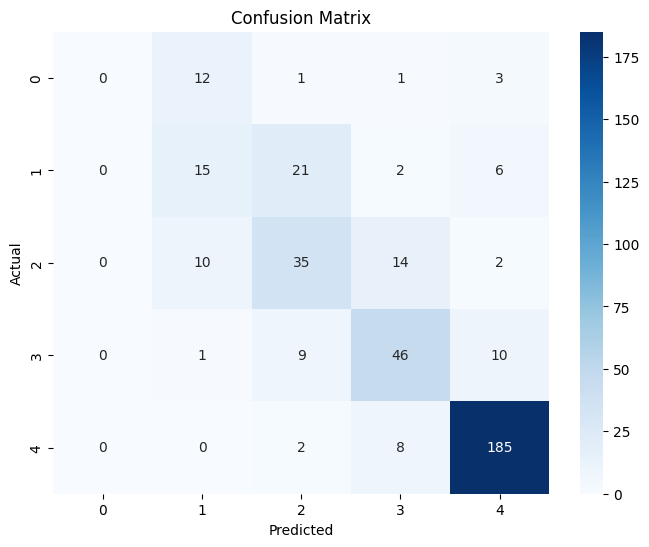

Validation Accuracy: 0.5005
Submission file saved as submission.csv


In [ ]:
""" TESTING LOGISTIC REGRESSION, SVM, NAIVE BAYES AND CATBOOST GRADIENT BOOSTING MODELS """

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

# model = LogisticRegression(random_state=42, max_iter=1000,solver='lbfgs',C=0.1)
# model = GaussianNB()
# model = CatBoostClassifier(random_state=42, verbose=0,learning_rate=0.1,l2_leaf_reg=7,iterations=100,depth=6)
model = SVC(kernel='poly',degree=2,C=5.0,random_state=42)

model = simple_tt_split(X, y, model,show_graphs=True)
# model = kfold_cv(X,y,model,k=5,show_graphs=True)
predict(X_test, test_ids, model, le, output_file='submission.csv')

Starting training...
Epoch 10/150, Loss: 1.1735, Val F1: 0.5074
Epoch 20/150, Loss: 1.0531, Val F1: 0.6089
Epoch 30/150, Loss: 1.0377, Val F1: 0.6546
Epoch 40/150, Loss: 1.0298, Val F1: 0.6122
Epoch 50/150, Loss: 1.0661, Val F1: 0.5372
Epoch 60/150, Loss: 1.0194, Val F1: 0.6172
Epoch 70/150, Loss: 1.0488, Val F1: 0.5233
Epoch 80/150, Loss: 1.0000, Val F1: 0.6494
Epoch 90/150, Loss: 0.9972, Val F1: 0.6632
Epoch 100/150, Loss: 1.0102, Val F1: 0.6204
Epoch 110/150, Loss: 1.0285, Val F1: 0.6417
Epoch 120/150, Loss: 1.0165, Val F1: 0.6620
Epoch 130/150, Loss: 0.9797, Val F1: 0.5698
Epoch 140/150, Loss: 0.9915, Val F1: 0.6704
Epoch 150/150, Loss: 1.0136, Val F1: 0.5962

Generating confusion matrix for validation set...

Confusion Matrix:
[[  3   9   1   1   3]
 [  0  26  10   4   4]
 [  0  13  30  16   2]
 [  0   1   6  54   5]
 [  0   1   0  21 173]]


<Figure size 1000x800 with 0 Axes>

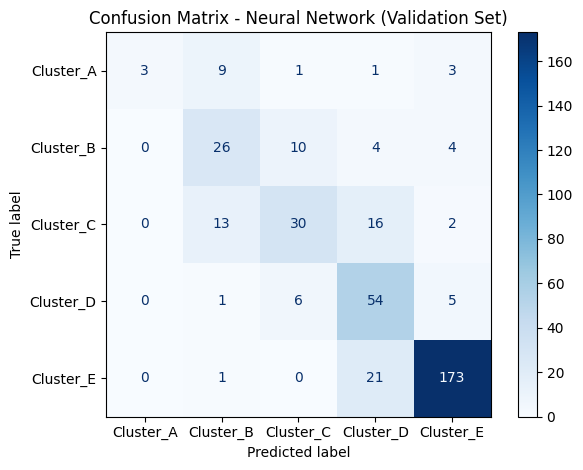


Classification Report:
              precision    recall  f1-score   support

   Cluster_A       1.00      0.18      0.30        17
   Cluster_B       0.52      0.59      0.55        44
   Cluster_C       0.64      0.49      0.56        61
   Cluster_D       0.56      0.82      0.67        66
   Cluster_E       0.93      0.89      0.91       195

    accuracy                           0.75       383
   macro avg       0.73      0.59      0.60       383
weighted avg       0.77      0.75      0.74       383


Submission file saved as submission.csv


In [ ]:
""" NEURAL NETWORK """

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,f1_score
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

torch.manual_seed(42)
class PersonalityDataset(Dataset):
    def __init__(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            X = X.values
        elif hasattr(X,'values'):
            X = X.values

        self.X = torch.tensor(X, dtype=torch.float32)

        if y is not None:
          if hasattr(y,'values'):
            y = y.values
          if isinstance(y, pd.Series):
            y = y.values

          self.y = torch.tensor(y, dtype=torch.long)
        else:
            self.y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

# Create Datasets
train_dataset = PersonalityDataset(X_train, y_train)
val_dataset = PersonalityDataset(X_val, y_val)
test_dataset = PersonalityDataset(X_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class NeuralNetwork(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            nn.Linear(128, 96),
            nn.BatchNorm1d(96),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.25),

            nn.Linear(96, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(64, 48),
            nn.BatchNorm1d(48),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.15),

            nn.Linear(48, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Initialize Model
input_size = X_train.shape[1]
num_classes = len(np.unique(y))

model = NeuralNetwork(input_size, num_classes)
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.015,weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

num_epochs = 150
print("Starting training...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- Validation Loop ---
    if (epoch+1) % 10 == 0:
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.numpy())
                all_labels.extend(labels.numpy())

        acc = f1_score(all_labels, all_preds, average='macro')
        scheduler.step(acc)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val F1: {acc:.4f}")

# --- Final Validation Predictions for Confusion Matrix ---
print("\nGenerating confusion matrix for validation set...")
model.eval()
val_preds = []
val_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        val_preds.extend(preds.numpy())
        val_labels.extend(labels.numpy())

# Generate Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Neural Network (Validation Set)')
plt.tight_layout()
plt.savefig('nn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate and print metrics per class
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(val_labels, val_preds,
                           target_names=le.classes_))

# --- Test Set Predictions ---
model.eval()
test_preds = []
with torch.no_grad():
    for inputs in test_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.numpy())

output_file = 'submission.csv'
submission_df = pd.DataFrame({
    'participant_id': test_ids,
    'personality_cluster': le.inverse_transform(test_preds)
})

submission_df.to_csv(output_file, index=False)
print(f'\nSubmission file saved as {output_file}')